In [1]:
import os
import glob
import re
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import welch

Let's try plotting the wave heights above mean lake level as a function of time for a particular point in lake, preferrably near/on the ramp and see how it looks!

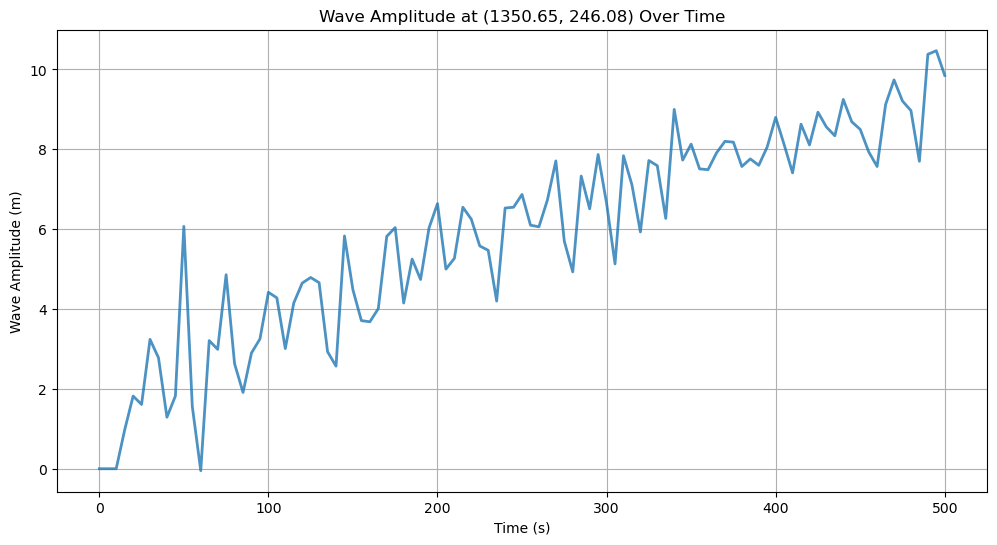

In [13]:
TARGET_COORD = (1350.65, 246.08) # (X,Y) coordinates of the point in the lake where we want to extract data!

TARGET_DIR = "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM10m/10m_results/10m_ascii" # Directory where the output ascii files are located
PREFIX = "10m" # Prefix used for running the simulation

def extract_wave_data(target_dir, prefix, target_coord):

    # Get list of all the required ascii files, the htsun files!
    search_pattern = os.path.join(
        target_dir,
        f"{prefix}_htsun[0-9][0-9][0-9][0-9].asc"
    )

    file_list = glob.glob(search_pattern)

    # Handle the case when no files are found
    if len(file_list) == 0:
        print("No files are found with the specified regex syntax")
        return [], []
    
    # Make a regex object to extract the time step from the filename
    pattern = re.compile(rf"{prefix}_htsun(\d{{4}})\.asc")
    sorted_pairs =[]

    for files in file_list:
        filename = os.path.basename(files)
        match = pattern.search(filename)
        if match is not None:
            time_step = int(match.group(1))
            sorted_pairs.append((time_step, files))
    
    sorted_pairs.sort(key=lambda x:x[0])

    time_steps = []
    for pair in sorted_pairs:
        time_steps.append(pair[0] * 5) # Data is extracted at 5s interval!

    ordered_files = []
    for pair in sorted_pairs:
        ordered_files.append(pair[1])
    
    wave_amplitudes = []

    for file in ordered_files:
        with rasterio.open(file) as src:
            coords = [target_coord] # Rasterio expects a list of coordinates

            sample_gen = src.sample(coords)
            sample = next(sample_gen)
            sample_val = sample[0] # rasterio returns an array, we only need the first value!

            if sample_val == src.nodata:
                wave_amplitudes.append(0.0)
            else:
                wave_amplitudes.append(sample_val)
    
    return time_steps, wave_amplitudes

plt.figure(figsize=(12,6))

ts, hs = extract_wave_data(TARGET_DIR, PREFIX, TARGET_COORD)
plt.plot(ts, hs, linewidth=2, alpha=0.8)
plt.title(f"Wave Amplitude at {TARGET_COORD} Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Wave Amplitude (m)")
plt.grid()
plt.show()

We want to extract the frequency of the wave. If you notice clearly we have two trends - a baseline which looks logarithmic or wtv the hell it is and on top of it we have superimposed tiny cosine or sine wiggles. First we need to extract the baseline trend using moving average. This would help me lower the curve to the normal ones and then we can do a FFT on it to get the frequencies

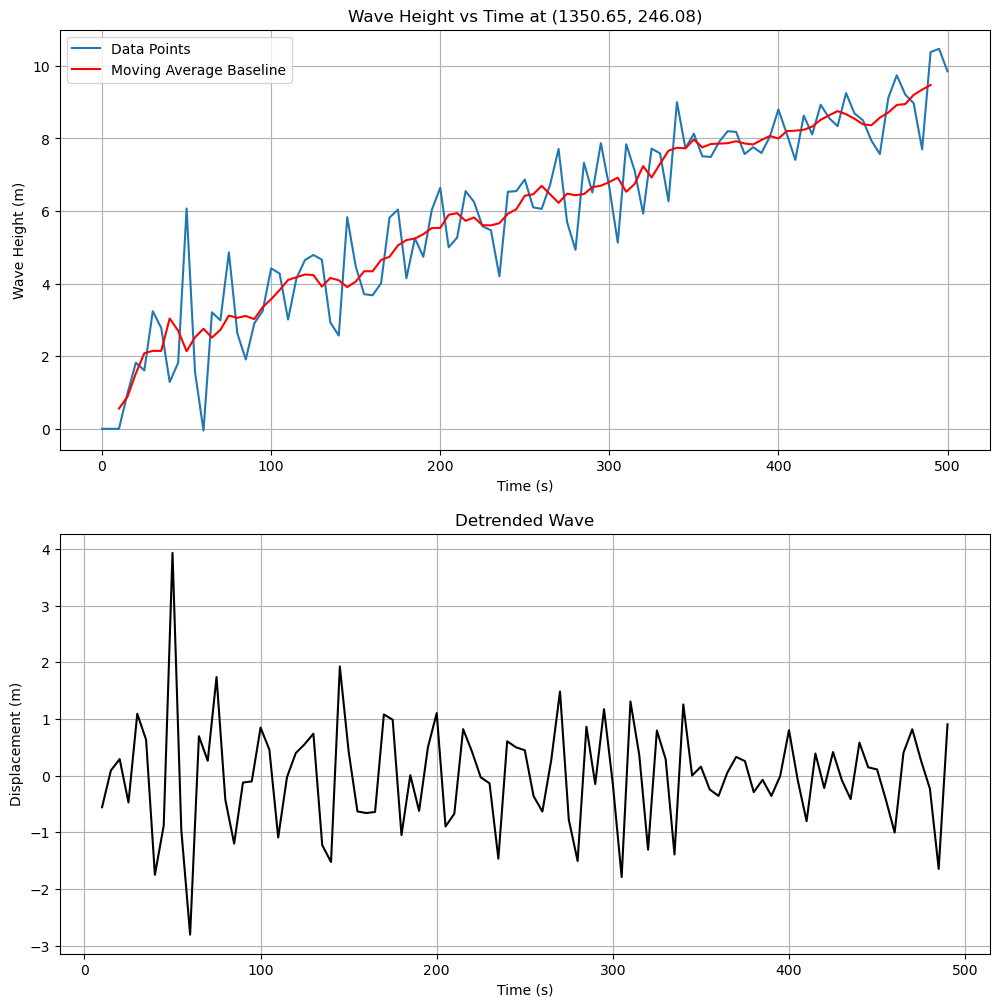

In [14]:
# Extract the raw data using your function
ts, hs = extract_wave_data(TARGET_DIR, PREFIX, TARGET_COORD)

# Convert lists to numpy arrays for mathematical processing
time_data = np.array(ts)
raw_amplitude = np.array(hs)

# Using Moving Average to estimate the base line

window_size = 5 
baseline = pd.Series(raw_amplitude).rolling(window=window_size, center=True).mean().values

# Subtract baseline from raw data to isolate the high-frequency waves
isolated_wave = raw_amplitude - baseline

# Remove NaN values created by the rolling window at the start and end
valid_idx = ~np.isnan(isolated_wave)
t_clean = time_data[valid_idx]
wave_clean = isolated_wave[valid_idx]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

ax1.plot(time_data, raw_amplitude, label="Data Points")
ax1.plot(time_data, baseline, color='red', label="Moving Average Baseline")
ax1.set_title(f"Wave Height vs Time at {TARGET_COORD}")
ax1.set_ylabel("Wave Height (m)")
ax1.set_xlabel("Time (s)")
ax1.legend()
ax1.grid(True)

ax2.plot(t_clean, wave_clean, color='black', label="Detrended Wave")
ax2.set_title("Detrended Wave")
ax2.set_ylabel("Displacement (m)")
ax2.set_xlabel("Time (s)")
ax2.grid(True)

Now we do a FFT and Power Spectra shit or wtv the fuck that is

Dominant Frequency: 0.041237113402061855 Hz
Dominant Period: 24.25 s


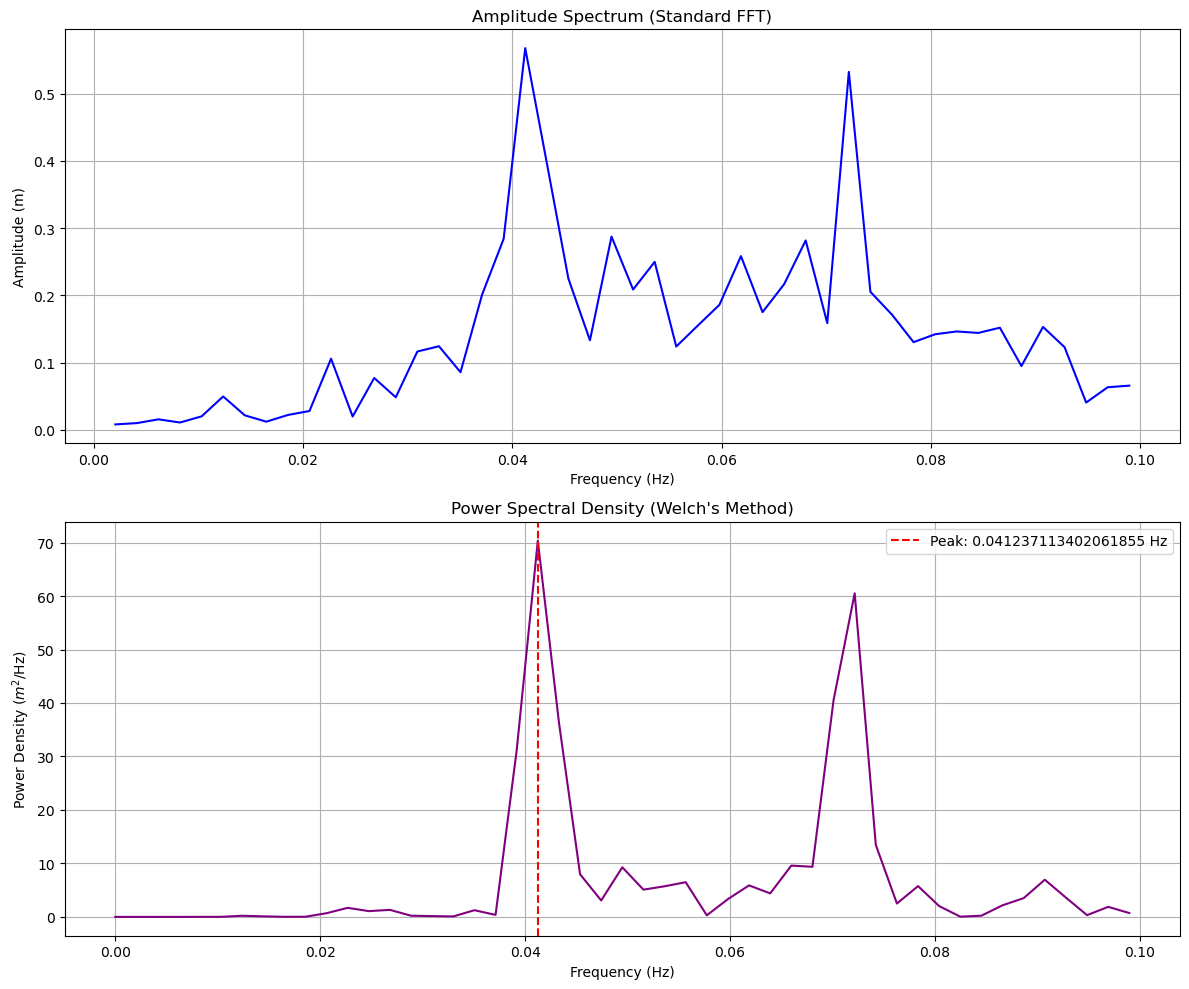

In [21]:
# Sampling parameters
dt = 5.0  # Time step in seconds 
fs = 1.0 / dt  # Sampling frequency in Hz
n = len(wave_clean)

# Fast Fourier Transform or FFT - very new stuff for me so took Gemini Pro help
fft_result = np.fft.fft(wave_clean)
freqs = np.fft.fftfreq(n, d=dt)

# Filter for positive frequencies only
pos_mask = freqs > 0
freqs_pos = freqs[pos_mask]
# Normalize the amplitude
fft_amp = np.abs(fft_result[pos_mask]) / n * 2  

# Power Spectral Density (Welch's Method)
# nperseg defines the window size for averaging; adjusting it trades frequency resolution for noise reduction
f_welch, pxx_welch = welch(wave_clean, fs=fs, nperseg=min(256, n)) 

# Find the dominant frequency from the Power Spectrum
dominant_idx = np.argmax(pxx_welch)
dominant_freq = f_welch[dominant_idx]

print(f"Dominant Frequency: {dominant_freq} Hz")
print(f"Dominant Period: {1/dominant_freq} s")

fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(12, 10))

# Plot Amplitude Spectrum
ax3.plot(freqs_pos, fft_amp, color='blue')
ax3.set_title("Amplitude Spectrum (Standard FFT)")
ax3.set_ylabel("Amplitude (m)")
ax3.set_xlabel("Frequency (Hz)")
ax3.grid(True)

# Plot Power Spectral Density
ax4.plot(f_welch, pxx_welch, color='purple')
ax4.axvline(dominant_freq, color='red', linestyle='--', label=f'Peak: {dominant_freq} Hz')
ax4.set_title("Power Spectral Density (Welch's Method)")
ax4.set_ylabel("Power Density ($m^2$/Hz)")
ax4.set_xlabel("Frequency (Hz)")
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

In [20]:
%matplotlib inline

# Effect of Changing Resolution:

We ran simulation for different resolution of DEMs - 5m, 10m, 20m, 40m. Now let's plot all of them in a single graph and look at the difference!

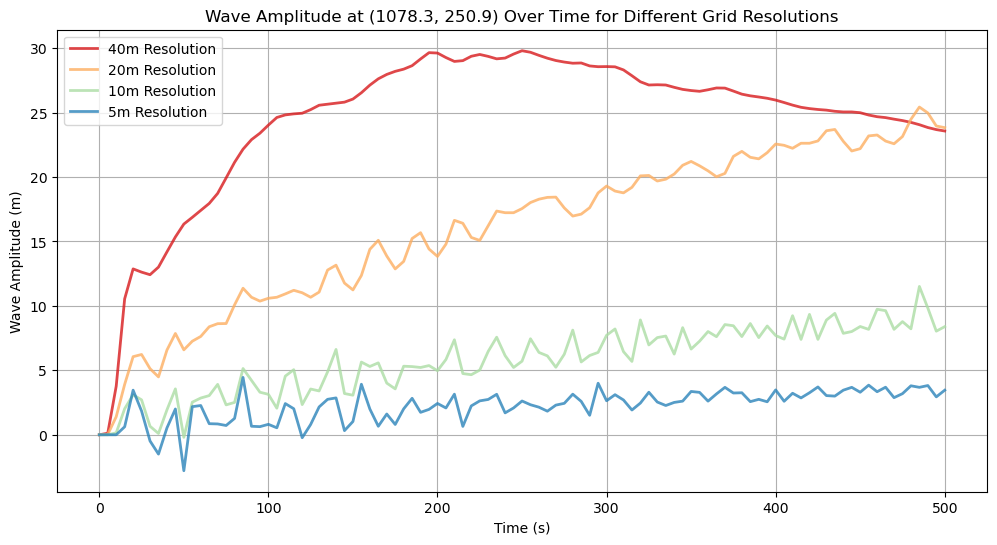

In [3]:
TARGET_COORD = (1078.3, 250.9) # (X,Y) coordinates of the point in the lake where we want to extract data!

TARGET_DIRS = {
    "40m Resolution": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM40m/40m_results/40m_ascii",
        "prefix": "40m" 
    },
    "20m Resolution": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM20m/20m_results/20m_ascii",
        "prefix": "20m"
    },
    "10m Resolution": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM10m/10m_results/10m_ascii",
        "prefix": "10m"
    },
    "5m Resolution": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM5m/5m_results/5m_ascii",
        "prefix": "5m"
    }
}

def extract_wave_data(target_dir, prefix, target_coord):

    # Get list of all the required ascii files, the htsun files!
    search_pattern = os.path.join(
        target_dir,
        f"{prefix}_htsun[0-9][0-9][0-9][0-9].asc"
    )

    file_list = glob.glob(search_pattern)

    # Handle the case when no files are found
    if len(file_list) == 0:
        print("No files are found with the specified regex syntax")
        return [], []
    
    # Make a regex object to extract the time step from the filename
    pattern = re.compile(rf"{prefix}_htsun(\d{{4}})\.asc")
    sorted_pairs =[]

    for files in file_list:
        filename = os.path.basename(files)
        match = pattern.search(filename)
        if match is not None:
            time_step = int(match.group(1))
            sorted_pairs.append((time_step, files))
    
    sorted_pairs.sort(key=lambda x:x[0])

    time_steps = []
    for pair in sorted_pairs:
        time_steps.append(pair[0] * 5) # Data is extracted at 5s interval!

    ordered_files = []
    for pair in sorted_pairs:
        ordered_files.append(pair[1])
    
    wave_amplitudes = []

    for file in ordered_files:
        with rasterio.open(file) as src:
            coords = [target_coord] # Rasterio expects a list of coordinates

            sample_gen = src.sample(coords)
            sample = next(sample_gen)
            sample_val = sample[0] # rasterio returns an array, we only need the first value!

            if sample_val == src.nodata:
                wave_amplitudes.append(0.0)
            else:
                wave_amplitudes.append(sample_val)
    
    return time_steps, wave_amplitudes

plt.figure(figsize=(12,6))

colors =["#d7191c", "#fdae61", "#abdda4", "#2b83ba"] # Different colors for the different plots to tell the grids apart

for (label, config), color in zip(TARGET_DIRS.items(), colors):
    ts, hs = extract_wave_data(config["dir"], config["prefix"], TARGET_COORD)
    plt.plot(ts, hs, label=label, linewidth=2, alpha=0.8, color=color)

plt.title(f"Wave Amplitude at {TARGET_COORD} Over Time for Different Grid Resolutions")
plt.xlabel("Time (s)")
plt.ylabel("Wave Amplitude (m)")

plt.legend()
plt.grid()
plt.show()

Quite a lot of variety in plots. Before analysing them, let's move to checking some basic volume conservation between solid and liquid phases.

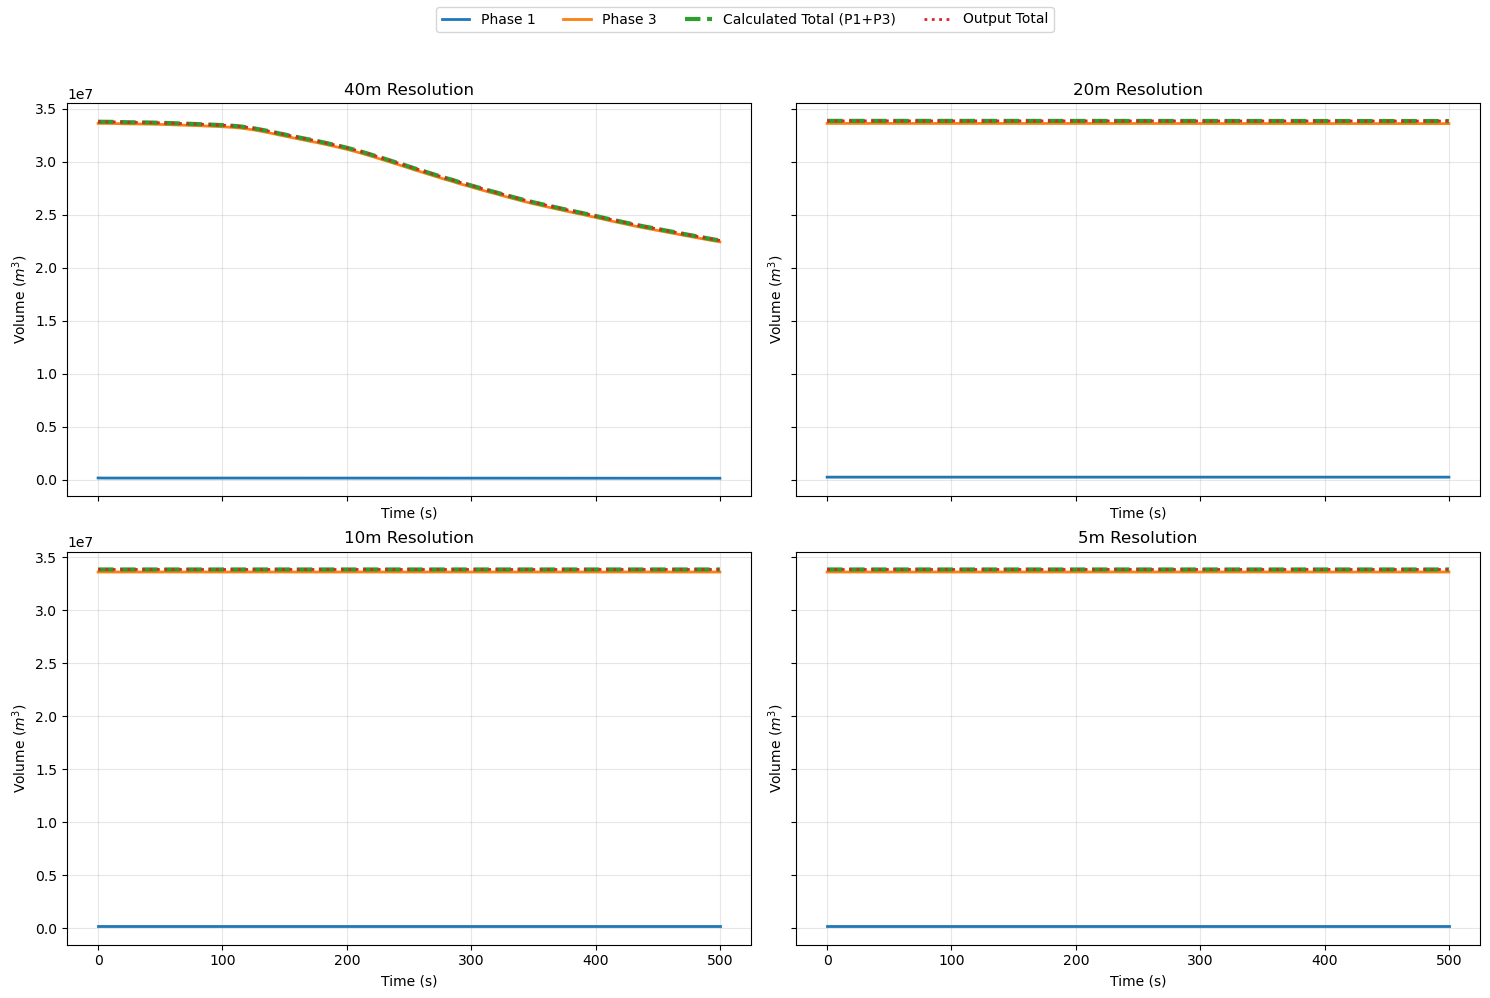

In [3]:
TARGET_DIRS = {
    "40m Resolution": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM40m/40m_results/40m_ascii",
        "prefix": "40m"
    },
    "20m Resolution": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM20m/20m_results/20m_ascii",
        "prefix": "20m"
    },
    "10m Resolution": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM10m/10m_results/10m_ascii",
        "prefix": "10m"
    },
    "5m Resolution": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/CellSize/DEM5m/5m_results/5m_ascii",
        "prefix": "5m"
    }
}

START_STEP = 0
END_STEP = 100

def calculate_volume(filepath):
    if not os.path.exists(filepath):
        return 0.0
        
    with rasterio.open(filepath) as src:
        data = src.read(1) # Read the first band

        nodata_val = src.nodata
        if nodata_val is not None:
            valid_data = (data != nodata_val) & (data >= 0)
        else:
            valid_data = (data >= 0)

        cell_area = src.res[0] * src.res[1] 
        volume = np.sum(data[valid_data]) * cell_area

    return volume

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)

axes = axes.flatten()

for ax, (label, config) in zip(axes, TARGET_DIRS.items()):

    base_dir = config["dir"]

    timesteps = []

    p1_vol = []
    p3_vol = []

    total_calc_vol = []
    total_out_vol = []

    for step in range(START_STEP, END_STEP + 1):
        step_str = f"{step:04d}"

        p1_file = os.path.join(
            base_dir,
            f"{config['prefix']}_hflow1{step_str}.asc"
        )

        p3_file = os.path.join(
            base_dir,
            f"{config['prefix']}_hflow3{step_str}.asc"
        )
        
        tot_file = os.path.join(
            base_dir,
            f"{config['prefix']}_hflow{step_str}.asc"
        )

        vol1 = calculate_volume(p1_file)
        vol3 = calculate_volume(p3_file)
        vol_out = calculate_volume(tot_file)

        total_calc = vol1 + vol3

        timesteps.append(step * 5) # Time in seconds

        p1_vol.append(vol1)
        p3_vol.append(vol3)

        total_calc_vol.append(total_calc)
        total_out_vol.append(vol_out)

    ax.plot(
        timesteps,
        p1_vol,
        label="Phase 1",
        linewidth=2
    )

    ax.plot(
        timesteps,
        p3_vol,
        label="Phase 3",
        linewidth=2
    )

    ax.plot(
        timesteps,
        total_calc_vol,
        label="Calculated Total (P1+P3)",
        linewidth=3,
        linestyle="--"
    )    
    
    ax.plot(
        timesteps,
        total_out_vol,
        label="Output Total",
        linewidth=2,
        linestyle=":"
    ) 

    ax.set_title(label)

    ax.grid(alpha=0.3)

    ax.set_xlabel("Time (s)")

    ax.set_ylabel("Volume ($m^3$)")  

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4
)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Effect of Changing Landslide stuff

Firstly, we need to know what matters more - is it the dimensions of the landslide block, i.e - length, thickness and so on, OR the total volume of the landslide?

To figure that out, we carry systematic tests!

In the first set of simulations we changed the dimensions of the landslide block, i.e - length and thickness. Width was kept constant!

Let's plot all of that in a single graph plane and observe!

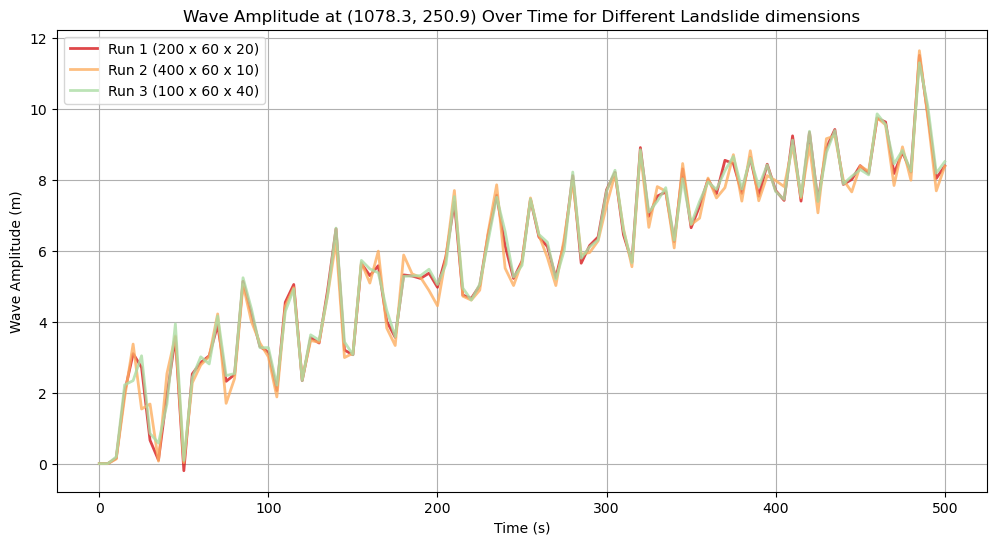

In [2]:
TARGET_COORD = (1078.3, 250.9) # (X,Y) coordinates of the point in the lake where we want to extract data!

TARGET_DIRS = {
    "Run 1 (200 x 60 x 20)": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test1/Test1_results/Test1_ascii",
        "prefix": "Test1"
    },
    "Run 2 (400 x 60 x 10)": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test2/Test2_results/Test2_ascii",
        "prefix": "Test2" 
    },
    "Run 3 (100 x 60 x 40)": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test3/Test3_results/Test3_ascii",
        "prefix": "Test3" 
    }
}

def extract_wave_data(target_dir, prefix, target_coord):

    # Get list of all the required ascii files, the htsun files!
    search_pattern = os.path.join(
        target_dir,
        f"{prefix}_htsun[0-9][0-9][0-9][0-9].asc"
    )

    file_list = glob.glob(search_pattern)

    # Handle the case when no files are found
    if len(file_list) == 0:
        print("No files are found with the specified regex syntax")
        return [], []
    
    # Make a regex object to extract the time step from the filename
    pattern = re.compile(rf"{prefix}_htsun(\d{{4}})\.asc")
    sorted_pairs =[]

    for files in file_list:
        filename = os.path.basename(files)
        match = pattern.search(filename)
        if match is not None:
            time_step = int(match.group(1))
            sorted_pairs.append((time_step, files))
    
    sorted_pairs.sort(key=lambda x:x[0])

    time_steps = []
    for pair in sorted_pairs:
        time_steps.append(pair[0] * 5) # Data is extracted at 5s interval!

    ordered_files = []
    for pair in sorted_pairs:
        ordered_files.append(pair[1])
    
    wave_amplitudes = []

    for file in ordered_files:
        with rasterio.open(file) as src:
            coords = [target_coord] # Rasterio expects a list of coordinates

            sample_gen = src.sample(coords)
            sample = next(sample_gen)
            sample_val = sample[0] # rasterio returns an array, we only need the first value!

            if sample_val == src.nodata:
                wave_amplitudes.append(0.0)
            else:
                wave_amplitudes.append(sample_val)
    
    return time_steps, wave_amplitudes

plt.figure(figsize=(12,6))

colors =["#d7191c", "#fdae61", "#abdda4", "#2b83ba"] # Different colors for the different plots to tell the grids apart

for (label, config), color in zip(TARGET_DIRS.items(), colors):
    ts, hs = extract_wave_data(config["dir"], config["prefix"], TARGET_COORD)
    plt.plot(ts, hs, label=label, linewidth=2, alpha=0.8, color=color)

plt.title(f"Wave Amplitude at {TARGET_COORD} Over Time for Different Landslide dimensions")
plt.xlabel("Time (s)")
plt.ylabel("Wave Amplitude (m)")

plt.legend()
plt.grid()
plt.show()

Now we ran simulations where we only varied the volume of the landslide block falling in the reservoir. Let's plot that in a single graph plane and observe!

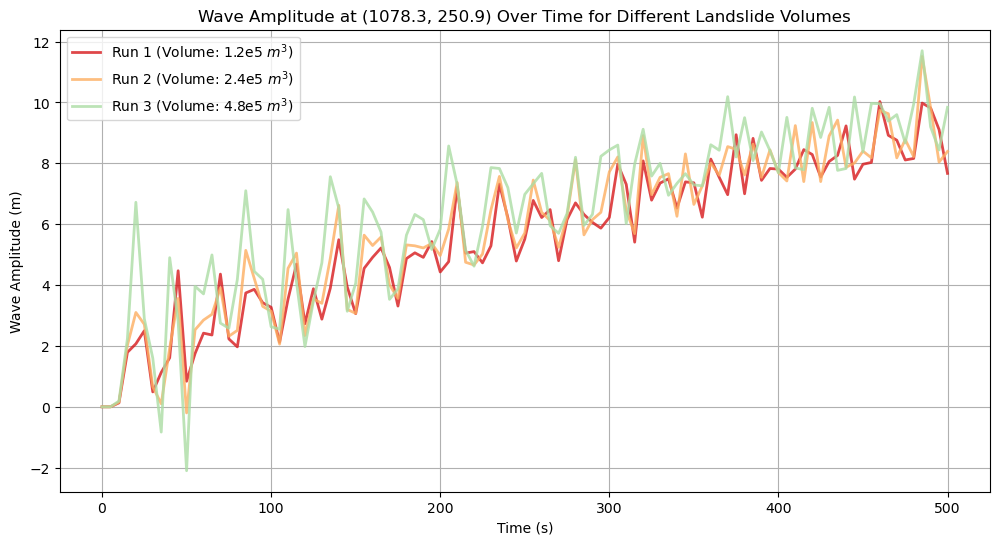

In [3]:
TARGET_COORD = (1078.3, 250.9) # (X,Y) coordinates of the point in the lake where we want to extract data!

TARGET_DIRS = {
    "Run 1 (Volume: 1.2e5 $m^3$)": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test4/Test4_results/Test4_ascii",
        "prefix": "Test4"
    },
    "Run 2 (Volume: 2.4e5 $m^3$)": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test1/Test1_results/Test1_ascii",
        "prefix": "Test1" 
    },
    "Run 3 (Volume: 4.8e5 $m^3$)": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test5/Test5_results/Test5_ascii",
        "prefix": "Test5" 
    }
}

def extract_wave_data(target_dir, prefix, target_coord):

    # Get list of all the required ascii files, the htsun files!
    search_pattern = os.path.join(
        target_dir,
        f"{prefix}_htsun[0-9][0-9][0-9][0-9].asc"
    )

    file_list = glob.glob(search_pattern)

    # Handle the case when no files are found
    if len(file_list) == 0:
        print("No files are found with the specified regex syntax")
        return [], []
    
    # Make a regex object to extract the time step from the filename
    pattern = re.compile(rf"{prefix}_htsun(\d{{4}})\.asc")
    sorted_pairs =[]

    for files in file_list:
        filename = os.path.basename(files)
        match = pattern.search(filename)
        if match is not None:
            time_step = int(match.group(1))
            sorted_pairs.append((time_step, files))
    
    sorted_pairs.sort(key=lambda x:x[0])

    time_steps = []
    for pair in sorted_pairs:
        time_steps.append(pair[0] * 5) # Data is extracted at 5s interval!

    ordered_files = []
    for pair in sorted_pairs:
        ordered_files.append(pair[1])
    
    wave_amplitudes = []

    for file in ordered_files:
        with rasterio.open(file) as src:
            coords = [target_coord] # Rasterio expects a list of coordinates

            sample_gen = src.sample(coords)
            sample = next(sample_gen)
            sample_val = sample[0] # rasterio returns an array, we only need the first value!

            if sample_val == src.nodata:
                wave_amplitudes.append(0.0)
            else:
                wave_amplitudes.append(sample_val)
    
    return time_steps, wave_amplitudes

plt.figure(figsize=(12,6))

colors =["#d7191c", "#fdae61", "#abdda4", "#2b83ba"] # Different colors for the different plots to tell the grids apart

for (label, config), color in zip(TARGET_DIRS.items(), colors):
    ts, hs = extract_wave_data(config["dir"], config["prefix"], TARGET_COORD)
    plt.plot(ts, hs, label=label, linewidth=2, alpha=0.8, color=color)

plt.title(f"Wave Amplitude at {TARGET_COORD} Over Time for Different Landslide Volumes")
plt.xlabel("Time (s)")
plt.ylabel("Wave Amplitude (m)")

plt.legend()
plt.grid()
plt.show()

As always, we will check for volume conservation!

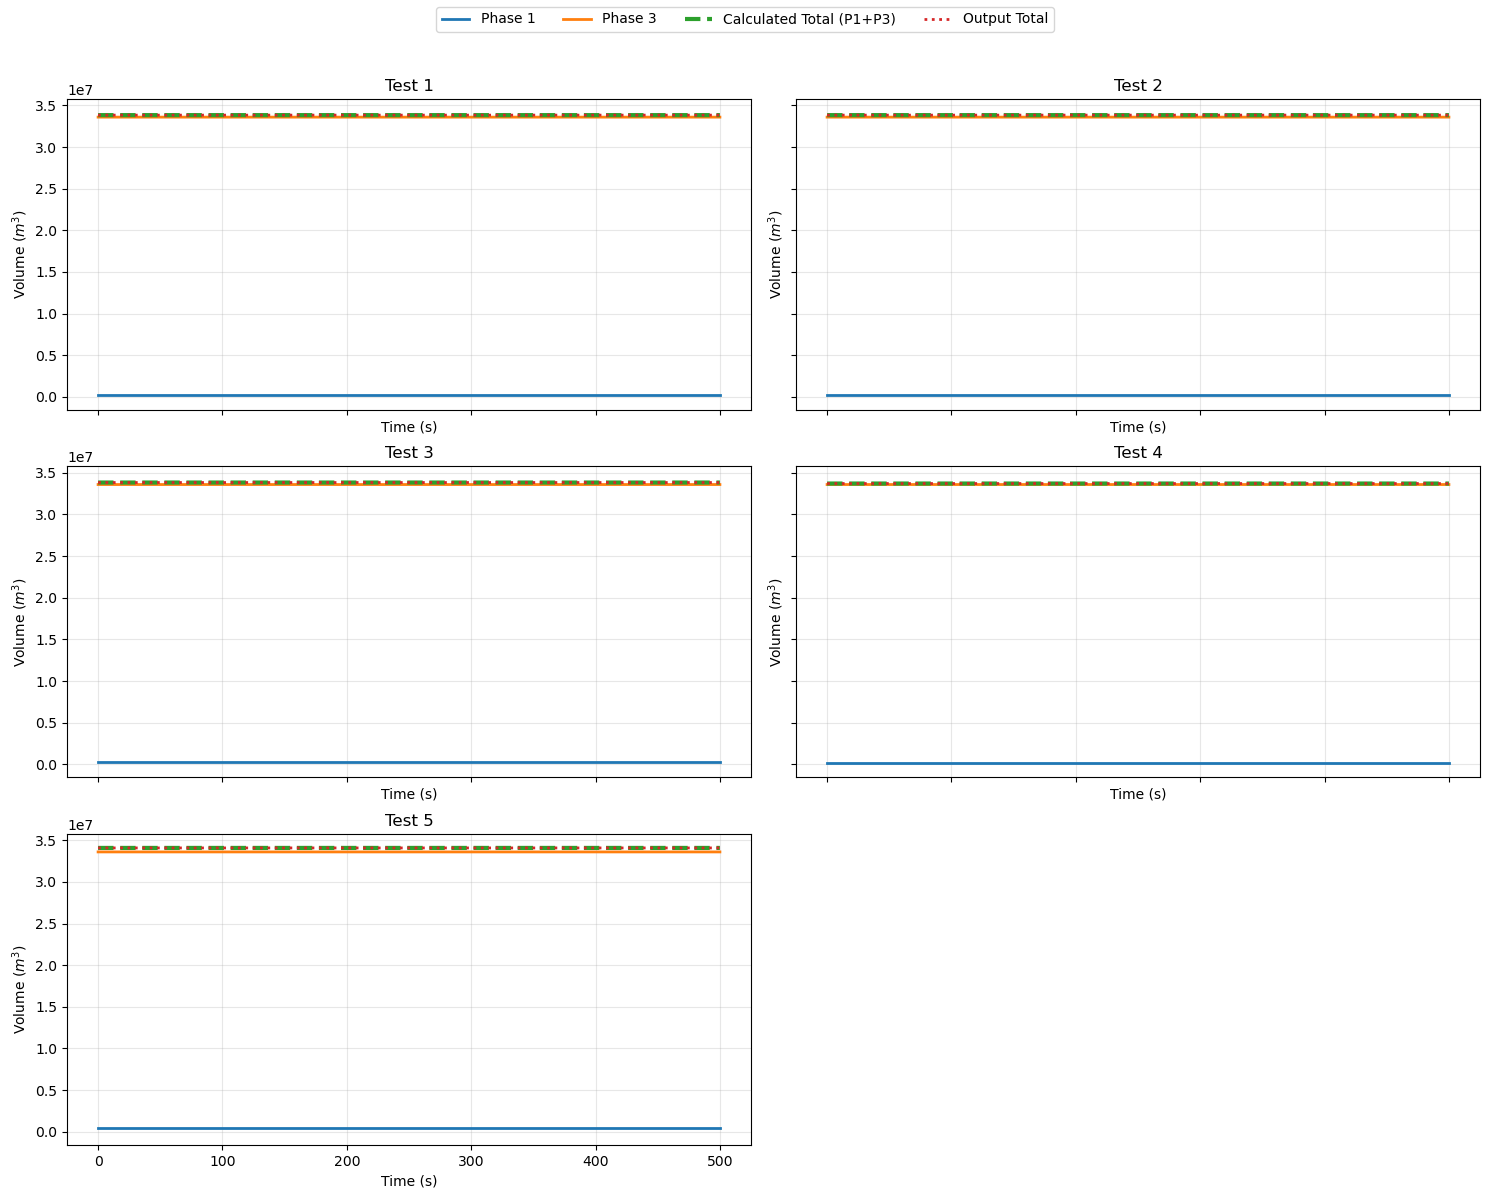

In [4]:
TARGET_DIRS = {

    "Test 1": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test1/Test1_results/Test1_ascii",
        "prefix": "Test1"
    },

    "Test 2": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test2/Test2_results/Test2_ascii",
        "prefix": "Test2" 
    },

    "Test 3": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test3/Test3_results/Test3_ascii",
        "prefix": "Test3" 
    },

    "Test 4": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test4/Test4_results/Test4_ascii",
        "prefix": "Test4" 
    },

    "Test 5": {
        "dir": "/home/anubrata/data/PROJECTS/ShallowWater/Volume_DimStudy/Test5/Test5_results/Test5_ascii",
        "prefix": "Test5" 
    }
}

START_STEP = 0
END_STEP = 100

def calculate_volume(filepath):
    if not os.path.exists(filepath):
        return 0.0

    with rasterio.open(filepath) as src:
        data = src.read(1) # Read the first band

        nodata_val = src.nodata
        if nodata_val is not None:
            valid_data = (data != nodata_val) & (data >= 0)
        else:
            valid_data = (data >= 0)

        cell_area = src.res[0] * src.res[1] 
        volume = np.sum(data[valid_data]) * cell_area

    return volume

fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True, sharey=True)

axes = axes.flatten()

for ax, (label, config) in zip(axes, TARGET_DIRS.items()):

    base_dir = config["dir"]

    timesteps = []

    p1_vol = []
    p3_vol = []

    total_calc_vol = []
    total_out_vol = []

    for step in range(START_STEP, END_STEP + 1):
        step_str = f"{step:04d}"

        p1_file = os.path.join(
            base_dir,
            f"{config['prefix']}_hflow1{step_str}.asc"
        )

        p3_file = os.path.join(
            base_dir,
            f"{config['prefix']}_hflow3{step_str}.asc"
        )
        
        tot_file = os.path.join(
            base_dir,
            f"{config['prefix']}_hflow{step_str}.asc"
        )

        vol1 = calculate_volume(p1_file)
        vol3 = calculate_volume(p3_file)
        vol_out = calculate_volume(tot_file)

        total_calc = vol1 + vol3

        timesteps.append(step * 5) # Time in seconds

        p1_vol.append(vol1)
        p3_vol.append(vol3)

        total_calc_vol.append(total_calc)
        total_out_vol.append(vol_out)

    ax.plot(
        timesteps,
        p1_vol,
        label="Phase 1",
        linewidth=2
    )

    ax.plot(
        timesteps,
        p3_vol,
        label="Phase 3",
        linewidth=2
    )

    ax.plot(
        timesteps,
        total_calc_vol,
        label="Calculated Total (P1+P3)",
        linewidth=3,
        linestyle="--"
    )    
    
    ax.plot(
        timesteps,
        total_out_vol,
        label="Output Total",
        linewidth=2,
        linestyle=":"
    ) 

    ax.set_title(label)

    ax.grid(alpha=0.3)

    ax.set_xlabel("Time (s)")

    ax.set_ylabel("Volume ($m^3$)")  

fig.delaxes(axes[5])
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4
)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()